In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [217]:
N = 1000
theta = 0.0001
theta_2 = 0.0001
r = int(0.1*N)


mu = np.zeros(N)
mu[[i for i in range(r)]] = theta

mu_2 = np.zeros(N)
mu_2[[i for i in range(r)]] += theta_2

Y = np.random.normal(0, 1, size=N)
Y_1 = Y + mu
Y_2 = Y_1 + mu_2

In [218]:
def square_diff(Y):
    mean = np.mean(Y)
    ss = (Y - mean)**2
    return np.sum(ss)

def diff_square_diff(Y, r):
    S = square_diff(Y)
    SL = square_diff(Y[:r+1])
    SR = square_diff(Y[r+1:])

    return S - SL - SR

def add_signal(Y, r, signal):
    X = Y.copy()
    X[[i for i in range(r)]] += signal
    return X

def diff_of_coupling(Y, r):
    Y_1 = add_signal(Y,r,theta)
    Y_2 = add_signal(Y_1,r,theta_2)

    diff = diff_square_diff(Y_2,r) - diff_square_diff(Y_1,r)

    return diff

In [219]:
Y = np.random.normal(0, 1, size=(N,N))
data = np.apply_along_axis(lambda x: diff_of_coupling(x, r), 0, Y)

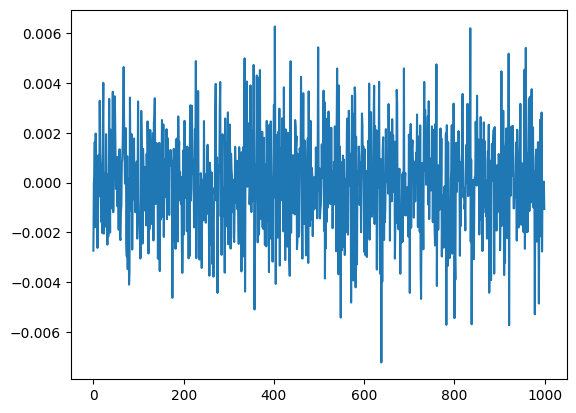

In [220]:
plt.plot(data)

In [221]:
np.sum(data < 0)/N

0.482

In [222]:
from scipy.stats import norm

In [223]:
norm.cdf(-(N-r)*(theta + theta_2)/(4*theta_2))

0.0